# Artificial Bee Colony (ABC) Optimization Algorithm

Welcome to this beginner-friendly implementation of the Artificial Bee Colony (ABC) algorithm! This notebook is designed as an educational tool for university-level projects to understand how swarm intelligence algorithms work.

We will implement the ABC algorithm for two cases:
1. **Minimization Problem:** Finding the minimum value of a function.
2. **Maximization Problem:** Finding the maximum value of a function.

### Standard Libraries Used
- `numpy`: For handling arrays and mathematical operations.
- `matplotlib.pyplot`: For plotting convergence curves.
- `random`: For generating random numbers and stochastic behaviors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

## 1. Parameters Setup
The ABC algorithm relies on several parameters. We define them clearly below so they can be easily modified.
- **Number of Bees (Swarm Size):** Total bees in the colony.
- **Number of Food Sources:** Half of the swarm are employed bees, and each is assigned to one food source.
- **Limit Parameter:** The number of trials a food source can endure without improvement before it is abandoned.
- **Maximum Iterations:** How many cycles the algorithm will run.
- **Search Space Bounds:** Minimum and maximum allowed values for our variables.

In [2]:
# ABC Model Parameters
num_bees = 40
num_food_sources = num_bees // 2
limit = 100
max_iterations = 100

# Problem Parameters (4 Decision Variables)
dimensions = 4
lower_bound = -10.0
upper_bound = 10.0

## 2. Minimization Problem

### Objective Function
We will use the Sphere function, a classic benchmark optimization problem:
$f(x_1, x_2, x_3, x_4) = x_1^2 + x_2^2 + x_3^2 + x_4^2$

The global minimum is at $x = (0, 0, 0, 0)$ where $f(x) = 0$.

### Fitness Function
The ABC algorithm maximizes fitness. For a minimization problem, a lower objective value should yield a higher fitness score.
- If $f(x) \geq 0$, $Fitness = \frac{1}{1 + f(x)}$
- If $f(x) < 0$, $Fitness = 1 + |f(x)|$

In [3]:
def objective_min(x):
    """Objective function for minimization."""
    return sum(xi**2 for xi in x)

def calculate_fitness_min(obj_val):
    """Convert objective value to fitness for minimization."""
    if obj_val >= 0:
        return 1.0 / (1.0 + obj_val)
    else:
        return 1.0 + abs(obj_val)

### Core Components of ABC Algorithm
Below are the modular functions that make up the initialization and the neighborhood search mechanism.

In [4]:
def initialize_population():
    """Generates initial food sources within the search space bounds."""
    population = []
    for _ in range(num_food_sources):
        solution = [random.uniform(lower_bound, upper_bound) for _ in range(dimensions)]
        population.append(solution)
    return population

def mutate_solution(current_solution, current_index, population):
    """Modifies one dimension of the current solution based on a random partner."""
    # Select a random partner different from the current index
    partner_index = random.choice([i for i in range(num_food_sources) if i != current_index])
    partner_solution = population[partner_index]
    
    # Select a random dimension to modify
    j = random.randint(0, dimensions - 1)
    
    # Create new solution
    new_solution = current_solution.copy()
    phi = random.uniform(-1, 1)
    new_solution[j] = current_solution[j] + phi * (current_solution[j] - partner_solution[j])
    
    # Boundary control
    if new_solution[j] < lower_bound:
        new_solution[j] = lower_bound
    elif new_solution[j] > upper_bound:
        new_solution[j] = upper_bound
        
    return new_solution

### Running the Minimization Simulation
We tie everything together into a clean, simple loop. We track the best solution over time to plot the convergence.

In [5]:
# --- Initialization ---
population = initialize_population()
fitness = [calculate_fitness_min(objective_min(x)) for x in population]
trials = [0] * num_food_sources

global_best_solution = None
global_best_fitness = -1.0
global_best_obj = float('inf')

convergence_curve_min = []

print("Starting ABC Minimization...")

for iteration in range(max_iterations):
    # --- 1. Employed Bee Phase ---
    for i in range(num_food_sources):
        new_solution = mutate_solution(population[i], i, population)
        new_obj = objective_min(new_solution)
        new_fitness = calculate_fitness_min(new_obj)
        
        # Greedy Selection
        if new_fitness > fitness[i]:
            population[i] = new_solution
            fitness[i] = new_fitness
            trials[i] = 0
        else:
            trials[i] += 1
            
    # --- 2. Onlooker Bee Phase ---
    # Calculate probabilities based on fitness
    total_fitness = sum(fitness)
    probabilities = [f / total_fitness for f in fitness]
    
    t = 0 # Onlooker bee counter
    i = 0 # Food source index
    while t < num_food_sources:
        if random.random() < probabilities[i]:
            t += 1
            new_solution = mutate_solution(population[i], i, population)
            new_obj = objective_min(new_solution)
            new_fitness = calculate_fitness_min(new_obj)
            
            if new_fitness > fitness[i]:
                population[i] = new_solution
                fitness[i] = new_fitness
                trials[i] = 0
            else:
                trials[i] += 1
        i = (i + 1) % num_food_sources
        
    # --- 3. Scout Bee Phase ---
    for i in range(num_food_sources):
        if trials[i] >= limit:
            # Abandon food source and generate a new random one
            population[i] = [random.uniform(lower_bound, upper_bound) for _ in range(dimensions)]
            fitness[i] = calculate_fitness_min(objective_min(population[i]))
            trials[i] = 0
            
    # --- 4. Update Global Best ---
    for i in range(num_food_sources):
        if fitness[i] > global_best_fitness:
            global_best_fitness = fitness[i]
            global_best_solution = population[i].copy()
            global_best_obj = objective_min(population[i])
            
    convergence_curve_min.append(global_best_obj)
    
    # Print progress every 10 iterations and the first/last
    if (iteration + 1) % 10 == 0 or iteration == 0:
        formatted_solution = [round(x, 4) for x in global_best_solution]
        print(f"Iteration {iteration + 1:3d} | Best Obj: {global_best_obj:10.6f} | Solution: {formatted_solution}")

print("\nFinal Best Objective (Minimization):", round(global_best_obj, 6))

Starting ABC Minimization...
Iteration   1 | Best Obj:   1.630795 | Solution: [-0.1375, 1.1485, -0.0208, -0.5408]
Iteration  10 | Best Obj:   0.002831 | Solution: [0.0046, 0.0156, -0.0095, 0.0498]
Iteration  20 | Best Obj:   0.000312 | Solution: [0.0063, -0.011, 0.0012, 0.0123]
Iteration  30 | Best Obj:   0.000027 | Solution: [0.002, -0.0002, 0.0007, -0.0048]
Iteration  40 | Best Obj:   0.000010 | Solution: [-0.0014, -0.0002, 0.0007, 0.0028]
Iteration  50 | Best Obj:   0.000003 | Solution: [-0.0003, -0.0002, 0.0006, 0.0016]
Iteration  60 | Best Obj:   0.000000 | Solution: [0.0004, -0.0001, -0.0001, 0.0001]
Iteration  70 | Best Obj:   0.000000 | Solution: [0.0, -0.0001, -0.0001, -0.0001]
Iteration  80 | Best Obj:   0.000000 | Solution: [0.0, -0.0, 0.0, 0.0]
Iteration  90 | Best Obj:   0.000000 | Solution: [0.0, 0.0, 0.0, 0.0]
Iteration 100 | Best Obj:   0.000000 | Solution: [-0.0, -0.0, -0.0, -0.0]

Final Best Objective (Minimization): 0.0


### Convergence Plot (Minimization)

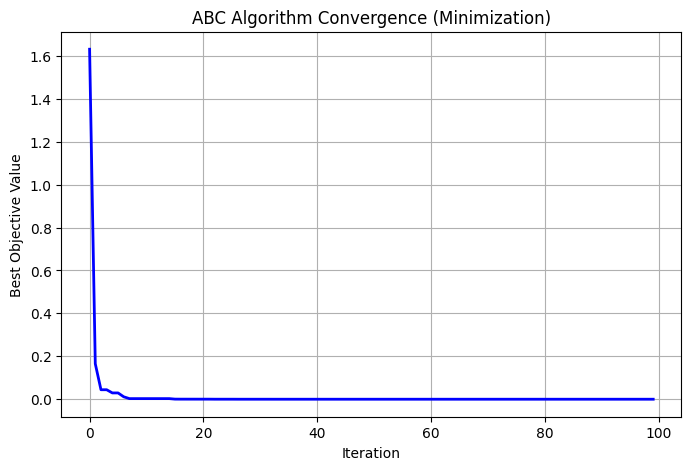

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(convergence_curve_min, color='blue', linewidth=2)
plt.title('ABC Algorithm Convergence (Minimization)')
plt.xlabel('Iteration')
plt.ylabel('Best Objective Value')
plt.grid(True)
plt.show()

---
## 3. Maximization Problem

### Objective Function
We invert our Sphere function to create a peak. We want to maximize:
$f(x_1, x_2, x_3, x_4) = 100 - (x_1^2 + x_2^2 + x_3^2 + x_4^2)$

The maximum possible value is 100, which occurs at $x = (0, 0, 0, 0)$.

### Fitness Function
In ABC, fitness must always be a positive value, and higher fitness means better solutions.
For maximization, we want to favor larger objective values.
- If $f(x) \geq 0$, $Fitness = 1 + f(x)$
- If $f(x) < 0$, $Fitness = \frac{1}{1 + |f(x)|}$

In [7]:
def objective_max(x):
    """Objective function for maximization."""
    return 100.0 - sum(xi**2 for xi in x)

def calculate_fitness_max(obj_val):
    """Convert objective value to fitness for maximization."""
    if obj_val >= 0:
        return 1.0 + obj_val
    else:
        return 1.0 / (1.0 + abs(obj_val))

### Running the Maximization Simulation

In [8]:
# --- Initialization ---
population_max = initialize_population()
fitness_max = [calculate_fitness_max(objective_max(x)) for x in population_max]
trials_max = [0] * num_food_sources

global_best_solution_max = None
global_best_fitness_max = -1.0
global_best_obj_max = float('-inf')

convergence_curve_max = []

print("Starting ABC Maximization...")

for iteration in range(max_iterations):
    # --- 1. Employed Bee Phase ---
    for i in range(num_food_sources):
        new_solution = mutate_solution(population_max[i], i, population_max)
        new_obj = objective_max(new_solution)
        new_fitness = calculate_fitness_max(new_obj)
        
        if new_fitness > fitness_max[i]:
            population_max[i] = new_solution
            fitness_max[i] = new_fitness
            trials_max[i] = 0
        else:
            trials_max[i] += 1
            
    # --- 2. Onlooker Bee Phase ---
    total_fitness = sum(fitness_max)
    probabilities = [f / total_fitness for f in fitness_max]
    
    t = 0
    i = 0
    while t < num_food_sources:
        if random.random() < probabilities[i]:
            t += 1
            new_solution = mutate_solution(population_max[i], i, population_max)
            new_obj = objective_max(new_solution)
            new_fitness = calculate_fitness_max(new_obj)
            
            if new_fitness > fitness_max[i]:
                population_max[i] = new_solution
                fitness_max[i] = new_fitness
                trials_max[i] = 0
            else:
                trials_max[i] += 1
        i = (i + 1) % num_food_sources
        
    # --- 3. Scout Bee Phase ---
    for i in range(num_food_sources):
        if trials_max[i] >= limit:
            population_max[i] = [random.uniform(lower_bound, upper_bound) for _ in range(dimensions)]
            fitness_max[i] = calculate_fitness_max(objective_max(population_max[i]))
            trials_max[i] = 0
            
    # --- 4. Update Global Best ---
    for i in range(num_food_sources):
        if fitness_max[i] > global_best_fitness_max:
            global_best_fitness_max = fitness_max[i]
            global_best_solution_max = population_max[i].copy()
            global_best_obj_max = objective_max(population_max[i])
            
    convergence_curve_max.append(global_best_obj_max)
    
    # Print progress every 10 iterations
    if (iteration + 1) % 10 == 0 or iteration == 0:
        formatted_solution = [round(x, 4) for x in global_best_solution_max]
        print(f"Iteration {iteration + 1:3d} | Best Obj: {global_best_obj_max:10.6f} | Solution: {formatted_solution}")

print("\nFinal Best Objective (Maximization):", round(global_best_obj_max, 6))

Starting ABC Maximization...
Iteration   1 | Best Obj:  56.451430 | Solution: [-3.2982, 5.3745, -1.8474, 0.6106]
Iteration  10 | Best Obj:  99.947450 | Solution: [0.0821, -0.1481, 0.1286, -0.0856]
Iteration  20 | Best Obj:  99.994750 | Solution: [0.0031, 0.0014, -0.0723, 0.0021]
Iteration  30 | Best Obj:  99.998015 | Solution: [0.0436, -0.0085, 0.0033, 0.0006]
Iteration  40 | Best Obj:  99.999992 | Solution: [0.0002, 0.0009, -0.0009, 0.0025]
Iteration  50 | Best Obj:  99.999999 | Solution: [0.0002, 0.0009, 0.0, -0.0005]
Iteration  60 | Best Obj: 100.000000 | Solution: [0.0, -0.0001, 0.0, -0.0005]
Iteration  70 | Best Obj: 100.000000 | Solution: [-0.0, 0.0001, 0.0, 0.0]
Iteration  80 | Best Obj: 100.000000 | Solution: [0.0, -0.0, -0.0, 0.0]
Iteration  90 | Best Obj: 100.000000 | Solution: [-0.0, -0.0, -0.0, 0.0]
Iteration 100 | Best Obj: 100.000000 | Solution: [0.0, 0.0, -0.0, 0.0]

Final Best Objective (Maximization): 100.0


### Convergence Plot (Maximization)

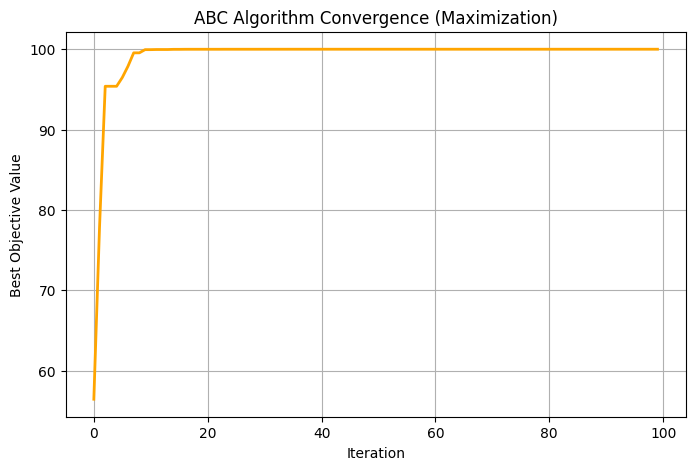

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(convergence_curve_max, color='orange', linewidth=2)
plt.title('ABC Algorithm Convergence (Maximization)')
plt.xlabel('Iteration')
plt.ylabel('Best Objective Value')
plt.grid(True)
plt.show()

---
## 4. Simulation Guidance: NetLogo Implementation

If you want to visualize this algorithm in **NetLogo** as an agent-based simulation for your project, here is a conceptual guide on how to structure it:

### Environment Setup (Patches)
- The NetLogo world (patches) acts as the search space. 
- Since our mathematical problem has 4 dimensions, you can visualize 2D projections (e.g., $x_1$ and $x_2$) on the spatial grid, and represent $x_3$ and $x_4$ as internal turtle variables (`turtles-own [x3 x4]`).
- Color the patches based on the objective function landscape (like a heatmap) to show "good" (high fitness) and "bad" (low fitness) areas.

### Agent Roles (Turtles)
Turtles represent the bees. You can define three distinct breeds or use a `state` variable to switch their roles.

1. **Employed Bees (`breed [employed-bees employed-bee]`)**
   - **Behavior:** Stationed at specific "food source" patches.
   - **Action:** At each tick, they look at another random food source, calculate a new position (using the $v_{ij} = x_{ij} + \phi (x_{ij} - x_{kj})$ formula), and test it. If the new patch has better fitness, they move to it; otherwise, they stay and increment their `trial-count`.

2. **Onlooker Bees (`breed [onlooker-bees onlooker-bee]`)**
   - **Behavior:** Wait in the "hive" (e.g., the center of the screen).
   - **Action:** Employed bees perform a "waggle dance" by sharing their fitness values globally. Onlooker bees use a roulette-wheel selection (using the `rnd` extension or custom cumulative probability logic) to pick a food source. They then fly to that source and perform the same neighborhood search as employed bees.

3. **Scout Bees (`breed [scout-bees scout-bee]`)**
   - **Behavior:** When an employed bee's `trial-count` exceeds the `limit`, it transforms into a scout bee.
   - **Action:** The scout bee picks a completely random coordinate in the environment to find a brand new food source, then transforms back into an employed bee.

### Visual Feedback
- **Links:** Draw temporary lines (`links`) between employed bees and their neighbors when mutating to visualize swarm communication.
- **Monitors:** Add NetLogo plots to track the "Best Fitness" over time, similar to the matplotlib graphs above.
- **Shapes/Colors:** Change the turtle shape or color to distinguish employed bees (e.g., green `bug`), onlookers (yellow `circle`), and scouts (red `star`).